In [1]:
import sys
sys.executable

'/home/maksi/projects/fraud-detection-api/.venv/bin/python'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)

In [7]:
train = pd.read_csv('../data/raw/fraudTrain.csv')
test = pd.read_csv('../data/raw/fraudTest.csv')


In [8]:
train.shape

(1296675, 23)

In [9]:
test.shape

(555719, 23)

## Dataset overview

The training dataset contains 1_296_675 transactions and 23 columns.  
The test dataset contains 555_719 transactions and has the same target column.

In [10]:
train.columns.tolist()

['Unnamed: 0',
 'trans_date_trans_time',
 'cc_num',
 'merchant',
 'category',
 'amt',
 'first',
 'last',
 'gender',
 'street',
 'city',
 'state',
 'zip',
 'lat',
 'long',
 'city_pop',
 'job',
 'dob',
 'trans_num',
 'unix_time',
 'merch_lat',
 'merch_long',
 'is_fraud']

In [11]:
train.dtypes.value_counts()

str        12
int64       6
float64     5
Name: count, dtype: int64

In [12]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  str    
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  str    
 4   category               1296675 non-null  str    
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  str    
 7   last                   1296675 non-null  str    
 8   gender                 1296675 non-null  str    
 9   street                 1296675 non-null  str    
 10  city                   1296675 non-null  str    
 11  state                  1296675 non-null  str    
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long                   129667

## Columns and data types

The dataset contains transaction, customer, merchant, location and target columns.  
Some columns have numeric dtype but should not be treated as regular numerical features, for example `cc_num`, `zip`, and `unix_time`.

## Data dictionary

| Column | Meaning |
|---|---|
| `Unnamed: 0` | Row index from the original dataset export (индекс строки из исходного CSV) |
| `trans_date_trans_time` | Transaction date and time (дата и время транзакции) |
| `cc_num` | Credit card / customer identifier (идентификатор карты или клиента) |
| `merchant` | Merchant name where the transaction was made (продавец / мерчант, у которого была совершена транзакция) |
| `category` | Merchant or transaction category (категория продавца или транзакции) |
| `amt` | Transaction amount (сумма транзакции) |
| `first` | Customer first name (имя клиента) |
| `last` | Customer last name (фамилия клиента) |
| `gender` | Customer gender (пол клиента) |
| `street` | Customer street address (улица / адрес клиента) |
| `city` | Customer city (город клиента) |
| `state` | Customer state (штат клиента) |
| `zip` | Customer ZIP code (почтовый индекс клиента) |
| `lat` | Customer latitude (широта местоположения клиента) |
| `long` | Customer longitude (долгота местоположения клиента) |
| `city_pop` | Population of the customer city (население города клиента) |
| `job` | Customer job title (профессия / должность клиента) |
| `dob` | Customer date of birth (дата рождения клиента) |
| `trans_num` | Transaction identifier (идентификатор транзакции) |
| `unix_time` | Transaction time in Unix timestamp format (время транзакции в Unix-формате) |
| `merch_lat` | Merchant latitude (широта местоположения продавца) |
| `merch_long` | Merchant longitude (долгота местоположения продавца) |
| `is_fraud` | Target variable: whether the transaction is fraudulent (целевая переменная: является ли транзакция мошеннической) |

In [13]:
target_counts = train['is_fraud'].value_counts()
target_ratio = train['is_fraud'].value_counts(normalize=True)

target_counts, target_ratio

(is_fraud
 0    1289169
 1       7506
 Name: count, dtype: int64,
 is_fraud
 0   0.9942
 1   0.0058
 Name: proportion, dtype: float64)

Text(0, 0.5, 'Count')

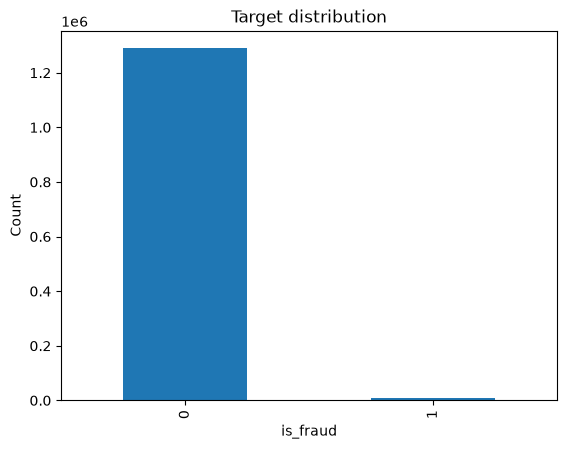

In [19]:
target_counts.plot(kind='bar')
plt.title('Target distribution')
plt.ylabel('Count')

## Target distribution conclusion

Fraudulent transactions are less than 1% of all transactions.  
The dataset is highly imbalanced.  
Accuracy is not suitable as the main metric because a model can predict all transactions as non-fraud and still achieve very high accuracy.

For this project, we should use ROC-AUC, PR-AUC, precision, recall, F1 and confusion matrix.

In [21]:
missing_count = train.isna().sum().sort_values(ascending=True)
missing_count

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

## Missing values conclusion

There are no missing values in the training dataset.  
At this stage, no imputation is required.

In [23]:
train.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1296675.0000,1296675.0000,1296675.0000,1296675.0000,1296675.0000,1296675.0000,1296675.0000,1296675.0000,1296675.0000,1296675.0000,1296675.0000
mean,648337.0000,417192042079726656.0000,70.3510,48800.6711,38.5376,-90.2263,88824.4406,1349243636.7261,38.5373,-90.2265,0.0058
std,374317.9745,1308806447000240384.0000,160.3160,26893.2225,5.0758,13.7591,301956.3607,12841278.4234,5.1098,13.7711,0.0759
min,0.0000,60416207185.0000,1.0000,1257.0000,20.0271,-165.6723,23.0000,1325376018.0000,19.0278,-166.6712,0.0000
25%,324168.5000,180042946491150.0000,9.6500,26237.0000,34.6205,-96.7980,743.0000,1338750742.5000,34.7336,-96.8973,0.0000
50%,648337.0000,3521417320836166.0000,47.5200,48174.0000,39.3543,-87.4769,2456.0000,1349249747.0000,39.3657,-87.4384,0.0000
75%,972505.5000,4642255475285942.0000,83.1400,72042.0000,41.9404,-80.1580,20328.0000,1359385375.5000,41.9572,-80.2368,0.0000
max,1296674.0000,4992346398065154048.0000,28948.9000,99783.0000,66.6933,-67.9503,2906700.0000,1371816817.0000,67.5103,-66.9509,1.0000


## Numeric statistics conclusion

Some columns are stored as numeric but should be interpreted carefully (probably like categorical features).

## First business conclusions

1. The dataset is suitable for a fraud detection ML project because it contains interpretable transaction, customer, merchant, time and location features.
2. The target is highly imbalanced: fraudulent transactions are less than 1% of all transactions.
3. Accuracy is not suitable as the main metric.
4. The dataset supports meaningful feature engineering: time features, customer behavior features, merchant/category risk features and geolocation-based features.
5. Identifier and personal information columns should not be used directly as model features.